# 01. Vanilla Regression Discontinuity for a Marketing Offer

This notebook is a self-contained introduction to a vanilla regression discontinuity design (RDD) using simulated marketing data.

We study a clean marketing example:
- Each month, a CRM model assigns every customer an eligibility score.
- Customers with a score at or above a fixed cutoff receive a high-value retention coupon.
- Customers just below the cutoff do not.
- The outcome is next-30-day spend.

The notebook walks through the full design: justify the threshold, clarify the assignment rule, inspect the data around the cutoff, and estimate the treatment effect with a continuity-based RDD specification.

## Learning Goals

By the end of this notebook, you should be able to:
- Explain the marketing problem and the source of the fixed threshold.
- Distinguish whether the design is sharp or fuzzy.
- Use exploratory data analysis to assess whether the cutoff looks arbitrary and whether observables are smooth at the threshold.
- Visualize the discontinuity in the outcome.
- Estimate a vanilla RDD with robust standard errors.
- Explain why we use robust standard errors here instead of clustering on a discrete variable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
rng = np.random.default_rng(123)

## Marketing Setup And Source Of The Threshold

Suppose a retailer sends a premium retention coupon to customers who appear most likely to respond. Each month, the CRM system recalculates an eligibility score from prior browsing, purchase, and engagement data.

The marketing operations team uses a **fixed threshold of 70** for a practical reason: the budget for premium coupons only covers the highest-priority tier. That tier has historically been defined as scores of 70 or above in the vendor's scoring system.

Why this matters:
- The threshold is operational, not behavioral.
- There is no economic reason customer demand should jump exactly at 70 in the absence of treatment.
- Customers just above and just below 70 should be very similar, which is the core intuition behind RDD.

Because treatment is assigned deterministically by whether the score crosses the cutoff, this is a **sharp RDD**.

In [2]:
n_customers = 240
n_months = 6
cutoff = 70
true_coupon_effect = 11

customers = pd.DataFrame({
    "customer_id": [f"C{i:03d}" for i in range(1, n_customers + 1)],
    "latent_affinity": rng.normal(0, 1, n_customers),
    "base_value_index": rng.normal(100, 14, n_customers),
    "tenure_months": rng.integers(6, 60, n_customers),
})

months = pd.DataFrame({"month": np.arange(1, n_months + 1)})
months["month_fe"] = np.array([-5, -2, 0, 2, 4, 6])

df = customers.assign(key=1).merge(months.assign(key=1), on="key").drop(columns="key")

df["eligibility_score"] = (
    70
    + 7 * df["latent_affinity"]
    + 0.08 * (df["base_value_index"] - 100)
    + 0.60 * df["month_fe"]
    + rng.normal(0, 7, len(df))
).clip(40, 100)

df["above_cutoff"] = (df["eligibility_score"] >= cutoff).astype(int)
df["treatment"] = df["above_cutoff"]

df["email_click_rate"] = np.clip(
    0.16
    + 0.010 * df["latent_affinity"]
    + 0.0010 * (df["eligibility_score"] - cutoff)
    + rng.normal(0, 0.015, len(df)),
    0.02,
    0.60,
)

df["prior_month_spend"] = (
    95
    + 9 * df["latent_affinity"]
    + 0.45 * (df["base_value_index"] - 100)
    + 1.0 * df["month_fe"]
    + 0.75 * (df["eligibility_score"] - cutoff)
    + rng.normal(0, 8, len(df))
).round(2)

df["customer_fe"] = 12 * df["latent_affinity"]
df["untreated_spend"] = (
    45
    + 0.70 * (df["eligibility_score"] - cutoff)
    + 0.18 * df["prior_month_spend"]
    + 35 * df["email_click_rate"]
    + df["customer_fe"]
    + df["month_fe"]
    + rng.normal(0, 7, len(df))
)

df["next_30_day_spend"] = (df["untreated_spend"] + true_coupon_effect * df["treatment"]).round(2)
df["score_centered"] = df["eligibility_score"] - cutoff

df[["customer_id", "month", "eligibility_score", "treatment", "prior_month_spend", "next_30_day_spend"]].head()

,customer_id,month,eligibility_score,treatment,prior_month_spend,next_30_day_spend
0,C001,1,44.097,0,63.290,40.680
1,C001,2,67.918,0,85.460,58.780
2,C001,3,72.093,1,98.730,68.730
3,C001,4,77.804,1,92.600,77.610
4,C001,5,65.202,0,101.740,46.070


## Is Assignment Completely Or Partly Determined By The Threshold?

In this example, assignment is **completely determined** by the running variable relative to the fixed cutoff:

\[
treatment_{it} = 1(eligibility\_score_{it} \geq 70)
\]

That makes this a sharp RDD rather than a fuzzy one.

In [3]:
assignment_check = pd.crosstab(df["above_cutoff"], df["treatment"])
assignment_check

treatment,0,1
above_cutoff,,
0,656,0
1,0,784


## Identification Logic

RDD relies on a continuity argument:
- Customers cannot precisely sort around the cutoff in a way that changes potential outcomes discontinuously.
- Baseline covariates and untreated potential outcomes should vary smoothly through the cutoff.
- Any sharp jump in the observed outcome at the cutoff is then attributed to treatment.

The key empirical question is whether score 70 is just an administrative line or whether something else fundamentally changes there. Exploratory checks help with that.

In [4]:
plot_bandwidth = 15
plot_df = df.loc[np.abs(df["score_centered"]) <= plot_bandwidth].copy()

def binned_means(data, outcome, bin_width=2):
    temp = data.copy()
    temp["bin_center"] = (
        np.floor(temp["score_centered"] / bin_width) * bin_width + bin_width / 2
    )
    summary = temp.groupby("bin_center", as_index=False)[outcome].mean()
    summary["score_plot"] = cutoff + summary["bin_center"]
    return summary.sort_values("score_plot")


## 1. Exploratory Data Analysis: Is The Threshold Arbitrary?

A first diagnostic is to inspect the distribution of the running variable around the cutoff. If the threshold is truly administrative and customers cannot precisely manipulate scores, the score density should look smooth near 70 rather than bunching just above it.

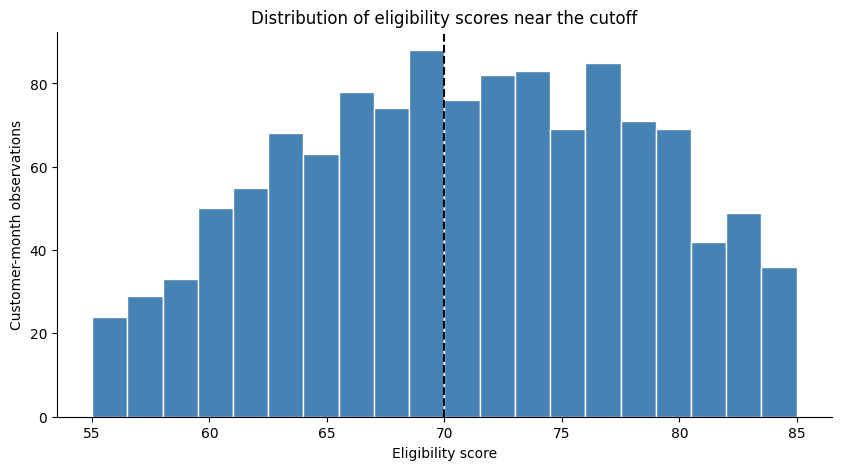

In [5]:
fig, ax = plt.subplots()
ax.hist(plot_df["eligibility_score"], bins=20, color="steelblue", edgecolor="white")
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Distribution of eligibility scores near the cutoff")
ax.set_xlabel("Eligibility score")
ax.set_ylabel("Customer-month observations")
plt.show()

If the histogram is smooth around 70, that supports the idea that the threshold is not tied to a structural break in who appears in the sample.

Next, examine whether predetermined covariates are continuous at the threshold. If these jump sharply at 70, that would weaken the design.

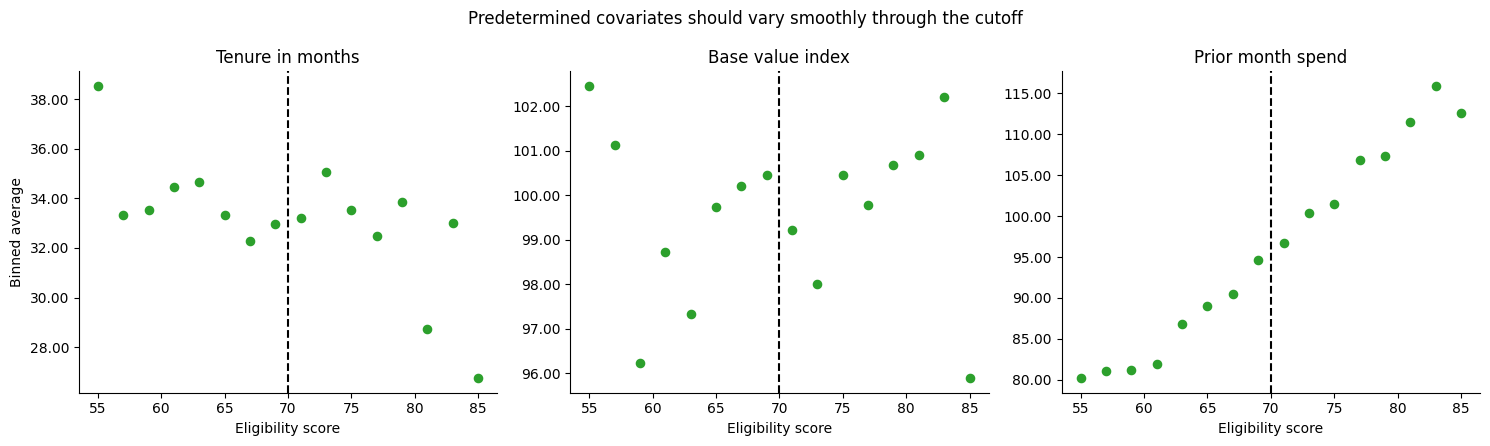

In [6]:
covariate_specs = [
    ("tenure_months", "Tenure in months"),
    ("base_value_index", "Base value index"),
    ("prior_month_spend", "Prior month spend"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for ax, (column, label) in zip(axes, covariate_specs):
    summary = binned_means(plot_df, column, bin_width=2)
    ax.scatter(summary["score_plot"], summary[column], color="tab:green", s=35)
    ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.5)
    ax.set_title(label)
    ax.set_xlabel("Eligibility score")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.2f}"))

axes[0].set_ylabel("Binned average")
plt.suptitle("Predetermined covariates should vary smoothly through the cutoff")
plt.tight_layout()
plt.show()

A useful placebo check is to run the same local regression on a pre-treatment variable. If there is no meaningful jump in prior month spend at the cutoff, that is consistent with the threshold being arbitrary rather than linked to an underlying discontinuity in demand.

In [7]:
rd_bandwidth = 12
rd_df = df.loc[np.abs(df["score_centered"]) <= rd_bandwidth].copy()

placebo_model = smf.ols(
    "prior_month_spend ~ treatment + score_centered + treatment:score_centered + C(customer_id) + C(month)",
    data=rd_df,
).fit(cov_type="HC3")

placebo_results = pd.DataFrame({
    "coefficient": placebo_model.params,
    "std_error": placebo_model.bse,
    "p_value": placebo_model.pvalues,
    "ci_low": placebo_model.conf_int()[0],
    "ci_high": placebo_model.conf_int()[1],
})

placebo_results.loc[["treatment"]].round(3)

,coefficient,std_error,p_value,ci_low,ci_high
treatment,0.749,1.176,0.524,-1.555,3.053


## 2. Visualize The Outcome Discontinuity

Now plot the outcome against the running variable. If the design is valid, the outcome should evolve smoothly with the score except for a jump at the threshold generated by the coupon assignment.

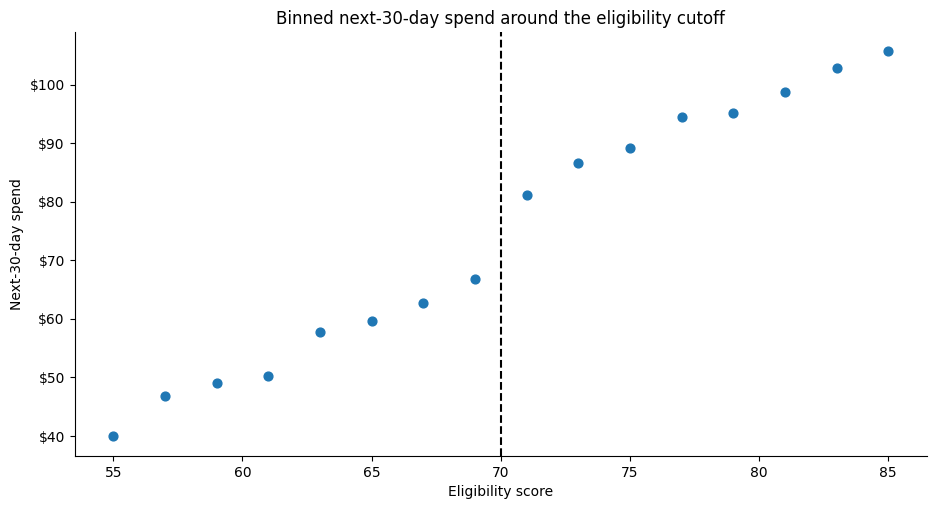

In [8]:
outcome_summary = binned_means(plot_df, "next_30_day_spend", bin_width=2)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(outcome_summary["score_plot"], outcome_summary["next_30_day_spend"], color="tab:blue", s=40)
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Binned next-30-day spend around the eligibility cutoff")
ax.set_xlabel("Eligibility score")
ax.set_ylabel("Next-30-day spend")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.show()

## 3. Apply The Regression Continuity Framework

We estimate a local linear RDD inside a symmetric bandwidth around the cutoff using the following framework:

\[
y_{it} = \beta \cdot I(z_{it} \geq \bar{z}) + \gamma X_{it} + \mu_i + \tau_t + \varepsilon_{it}
\]

Here:
- \(y_{it}\) is next-30-day spend for customer \(i\) in month \(t\).
- \(I(z_{it} \geq \bar{z})\) is the treatment indicator for crossing the score cutoff.
- \(X_{it}\) includes a smooth function of the running variable and pre-treatment controls.
- \(\mu_i\) are customer fixed effects.
- \(\tau_t\) are month fixed effects.

Operationally, we include `score_centered`, `treatment:score_centered`, `prior_month_spend`, and `email_click_rate` in `X_it`. The coefficient on `treatment` is the estimated jump at the cutoff.

In [9]:
rd_model = smf.ols(
    "next_30_day_spend ~ treatment + score_centered + treatment:score_centered + prior_month_spend + email_click_rate + C(customer_id) + C(month)",
    data=rd_df,
).fit(cov_type="HC3")

rd_results = pd.DataFrame({
    "coefficient": rd_model.params,
    "std_error": rd_model.bse,
    "p_value": rd_model.pvalues,
    "ci_low": rd_model.conf_int()[0],
    "ci_high": rd_model.conf_int()[1],
})

rd_results.loc[["treatment", "score_centered", "treatment:score_centered", "prior_month_spend", "email_click_rate"]].round(3)

,coefficient,std_error,p_value,ci_low,ci_high
treatment,11.087,1.028,0.000,9.072,13.103
score_centered,0.712,0.130,0.000,0.457,0.966
treatment:score_centered,-0.153,0.168,0.362,-0.483,0.176
prior_month_spend,0.221,0.034,0.000,0.155,0.287
email_click_rate,48.242,18.598,0.009,11.792,84.693


In [10]:
estimated_jump = rd_model.params["treatment"]
placebo_jump = placebo_model.params["treatment"]

print(f"Bandwidth used: +/- {rd_bandwidth} score points")
print(f"Observations in the local RD sample: {len(rd_df)}")
print(f"Estimated RDD jump at the cutoff: {estimated_jump:.2f}")
print(f"True simulated coupon effect: {true_coupon_effect:.2f}")
print(f"Placebo jump in prior month spend: {placebo_jump:.2f}")

Bandwidth used: +/- 12 score points
Observations in the local RD sample: 1087
Estimated RDD jump at the cutoff: 11.09
True simulated coupon effect: 11.00
Placebo jump in prior month spend: 0.75


## Why Robust Standard Errors Instead Of Clustering?

For this instructional notebook, we use **heteroskedasticity-robust standard errors** via `HC3`.

That choice matches your requirement and avoids a common mistake in RDD practice: clustering on a coarse discrete variable such as score bins, rounded score values, or the above/below-cutoff indicator. Those are not natural cluster units here.

The object of inference is the discontinuity at a fixed threshold, so the main priority in this basic setup is a correctly specified local design and robust inference, not arbitrary clustering on discrete score groups.

## Takeaways

- The marketing threshold is justified by an operational coupon budget rule, not by a known economic break in customer demand.
- Treatment is fully determined by whether the CRM score crosses 70, so this is a sharp RDD.
- Smooth score density, smooth pre-treatment covariates, and a near-zero placebo jump support the continuity argument.
- The estimated treatment effect is the jump in next-30-day spend at the cutoff.
- In this notebook, we use robust standard errors and explicitly do not cluster on a discrete variable.

In [11]:
summary = pd.Series({
    "True coupon effect": true_coupon_effect,
    "Estimated RD jump": round(estimated_jump, 2),
    "Placebo jump": round(placebo_jump, 2),
    "Local sample size": len(rd_df),
})
summary

True coupon effect      11.000
Estimated RD jump       11.090
Placebo jump             0.750
Local sample size    1,087.000
dtype: float64